In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from collections import OrderedDict

### Import simbo

In [2]:
from pathlib import Path
import sys

def find_repo_root(start):
    for path in [start, *start.parents]:
        if (path / "stbo").is_dir() and (path / "examples").is_dir():
            return path
    raise RuntimeError(f"Could not find stBO repo root from {start}")

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from stbo.optimization import BOController
from stbo.utils import live_monitor_plot, live_history_plot

### Construct machineIO

In [3]:
machineio_repo = repo_root / "machineIO"
machineio_package = machineio_repo / "machineIO"
if not (machineio_package / "__init__.py").exists():
    raise RuntimeError(f"Could not find machineIO package under {machineio_repo}")

loaded_machineio = sys.modules.get("machineIO")
if loaded_machineio is not None:
    loaded_file = getattr(loaded_machineio, "__file__", None)
    loaded_is_expected = loaded_file is not None and str(Path(loaded_file).resolve()).startswith(str(machineio_package.resolve()))
    if not loaded_is_expected:
        for module_name in [name for name in list(sys.modules) if name == "machineIO" or name.startswith("machineIO.")]:
            del sys.modules[module_name]

if str(machineio_repo) not in sys.path:
    sys.path.insert(0, str(machineio_repo))
from machineIO import construct_machineIO, Evaluator, OracleEvaluator
from machineIO.objFunc import SingleTaskObjectiveFunction
from machineIO.VM import VirtualMachineIO
# io = construct_machineIO()

Failed to import 'phantasy'


### optimizer settings

In [4]:
n_init = 4
n_global = 0
n_local = 16
n_finetune = 2

local_init = n_global == 0

# define control knobs

In [5]:
n_control = 4
n_bpm = 3
n_bcm = 1
n_fc = 1
n_monitor = n_bpm*3 + n_bcm + n_fc

control_CSETs= [f'X{i+1}:I_CSET' for i in range(n_control)]
control_RDs  = [f'X{i+1}:I_RD' for i in range(n_control)]
control_tols = np.array([0.1]*len(control_CSETs))
control_min  = np.array([ -2]*len(control_CSETs))
control_max  = np.array([  2]*len(control_CSETs))
bpm_xRDs     = [f'BPM{i+1}:XPOS_RD' for i in range(n_bpm)]
bpm_yRDs     = [f'BPM{i+1}:YPOS_RD' for i in range(n_bpm)]
bpm_phRDs    = [f'BPM{i+1}:PHASE_RD' for i in range(n_bpm)]
current_RDs  = [f'BCM:PKAVG_RD', f'FC:PKAVG_RD']
oracle_key_names = {
    'x':control_RDs,
    'y':'composite_obj'
}

control_bounds = torch.tensor([control_min, control_max], dtype=torch.float64)

C:\Users\HWANG\AppData\Local\Temp\ipykernel_85860\3486417315.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:248.)
  control_bounds = torch.tensor([control_min, control_max], dtype=torch.float64)


# define objectives

In [6]:
FC814 = 50

objective_goal = OrderedDict([
    ('BPM1:XPOS_RD',  -0.345812289535008),
    ('BPM1:YPOS_RD',   0.2755291980547795),
    ('BPM1:PHASE_RD', 80.01379620843083),
    ('BPM2:XPOS_RD',   0.11800521457630664),
    ('BPM2:YPOS_RD',   0.4313544346071099),
    ('BPM2:PHASE_RD', -23.42850231099402),
    ('BPM3:XPOS_RD',   0.04434067124873937),
    ('BPM3:YPOS_RD',  -0.15548171891011758),
    ('BPM3:PHASE_RD', -14.992799801690156),
    ('BCM:PKAVG_RD',  {'more than': FC814}),
    ('FC:PKAVG_RD',   {'more than': 0.8 * FC814}),
])

objective_tolerance = OrderedDict([
    ('BPM1:XPOS_RD',  1),
    ('BPM1:YPOS_RD',  1),
    ('BPM1:PHASE_RD', 1),
    ('BPM2:XPOS_RD',  1),
    ('BPM2:YPOS_RD',  1),
    ('BPM2:PHASE_RD', 1),
    ('BPM3:XPOS_RD',  1),
    ('BPM3:YPOS_RD',  1),
    ('BPM3:PHASE_RD', 1),
    ('BCM:PKAVG_RD',  0.01 * FC814),
    ('FC:PKAVG_RD',   0.05 * 0.8 * FC814),
])

objective_weight = OrderedDict([
    ('BPM1:XPOS_RD',  0.8),
    ('BPM1:YPOS_RD',  0.8),
    ('BPM1:PHASE_RD', 1),
    ('BPM2:XPOS_RD',  0.3),
    ('BPM2:YPOS_RD',  0.3),
    ('BPM2:PHASE_RD', 0.5),
    ('BPM3:XPOS_RD',  0.1),
    ('BPM3:YPOS_RD',  0.1),
    ('BPM3:PHASE_RD', 0.3),
    ('BCM:PKAVG_RD',  2),
    ('FC:PKAVG_RD',   2),
])


In [7]:
monitor_PVs  = []
monitor_min  = []
monitor_max  = []

for k in objective_goal.keys():
    monitor_PVs.append(k)
    goal = objective_goal[k]
    if isinstance(goal,dict):
        goal = list(goal.values())[0]
    tol = objective_tolerance[k]
    monitor_min.append(goal - 3*tol)
    monitor_max.append(goal + 3*tol)
    


io = VirtualMachineIO(
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    monitor_PVs = monitor_PVs,
    control_min = control_min,
    control_max = control_max,
    monitor_min = monitor_min,
    monitor_max = monitor_max,
    fetch_data_time_span = 1.0
)
io.x = np.random.rand(len(control_max))*(control_max - control_min) + control_min

# setup and test evaluator and oracle

In [8]:
ev =  Evaluator(
    io,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    monitor_PVs  = monitor_PVs,
)
ev.read().head()

,X1:I_CSET,X2:I_CSET,X3:I_CSET,X4:I_CSET,X1:I_RD,X2:I_RD,X3:I_RD,X4:I_RD,BPM1:XPOS_RD,BPM1:YPOS_RD,BPM1:PHASE_RD,BPM2:XPOS_RD,BPM2:YPOS_RD,BPM2:PHASE_RD,BPM3:XPOS_RD,BPM3:YPOS_RD,BPM3:PHASE_RD,BCM:PKAVG_RD,FC:PKAVG_RD
2026-07-07 11:58:31.886576,1.75656,0.763885,-0.964167,1.48238,1.756619,0.764169,-0.963940,1.482521,1.964140,-0.232581,81.410250,1.647524,-1.113088,-22.891353,2.247589,-1.816239,-12.759303,48.869211,40.009116
2026-07-07 11:58:32.086576,1.75656,0.763885,-0.964167,1.48238,1.756812,0.764168,-0.964066,1.482598,1.964017,-0.232548,81.410182,1.647799,-1.113057,-22.891171,2.247694,-1.816169,-12.759092,48.869188,40.008753
2026-07-07 11:58:32.286576,1.75656,0.763885,-0.964167,1.48238,1.756568,0.763978,-0.963993,1.482631,1.964023,-0.232535,81.410350,1.647617,-1.113255,-22.891305,2.247609,-1.816263,-12.759283,48.869280,40.008926
2026-07-07 11:58:32.486576,1.75656,0.763885,-0.964167,1.48238,1.756795,0.764198,-0.963843,1.482686,1.964041,-0.232560,81.410225,1.647663,-1.113105,-22.891222,2.247615,-1.816206,-12.759253,48.869220,40.008926
2026-07-07 11:58:32.686576,1.75656,0.763885,-0.964167,1.48238,1.756896,0.763919,-0.964024,1.482737,1.963923,-0.232485,81.410256,1.647957,-1.113193,-22.890809,2.247811,-1.816068,-12.759069,48.869265,40.008708


In [9]:
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = list(objective_goal.keys()), 
    composite_objective_name = 'composite_obj',
    objective_goal = objective_goal,
    objective_weight = objective_weight,
    objective_tolerance = objective_tolerance,
    p_order = 2,
    apply_bilog = True
)

In [10]:
oracle =  OracleEvaluator(
    io,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    oracle_key_names = oracle_key_names,
    monitor_PVs  = monitor_PVs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

In [11]:
oracle()

{'x': array([ 1.75676449,  0.76403862, -0.96396526,  1.48252699]),
 'y': array([-1.09349751]),
 'timing': {'oracle_fetch_data': 0.0036184999626129866,
  'oracle_validate_data': 0.0054805000545457006,
  'oracle_df_manipulators': 0.05304459994658828,
  'oracle_read_total': 0.062143599963746965,
  'oracle_result_processing': 0.003029600018635392,
  'oracle_call_total': 0.06519250001292676}}

# run BO

In [12]:
bo = BOController(oracle, 
                  bounds = control_bounds)

In [13]:
monitor_groups = [bpm_xRDs,bpm_yRDs,current_RDs,*[[pv] for pv in bpm_phRDs]]
control_CSETs_groups = [control_CSETs]
control_RDs_groups = [control_RDs]


monitor_live = live_monitor_plot(
    bo, oracle,
    monitor_groups       = monitor_groups,      
    control_CSETs_groups = control_CSETs_groups,
    control_RDs_groups   = control_RDs_groups,
)
history_live = live_history_plot(bo)

monitor_live.start()
history_live.start()

In [14]:
ramping_rate = np.ones(len(control_CSETs))
ramping_rate = None
seed = None

bo.initialize(budget=n_init, local_init=local_init, ramping_rate=ramping_rate, seed=seed)

In [15]:
for _ in range(n_global):
    fresh_train = (not bool(_%2)) or len(bo.train_x) < bo.bounds.shape[1]*2
    bo.step(mode="global", acq_type="qEI", fresh_train=fresh_train, plot_acq=False, asynchro=True)
    plt.show()

In [16]:
for _ in range(n_local):
    fresh_train = (not bool(_%2)) or len(bo.train_x) < bo.bounds.shape[1]*2
    bo.step(mode="local", acq_type="qEI", fresh_train=fresh_train, plot_acq=False, asynchro=True)
    plt.show()

In [17]:
for _ in range(n_finetune):
    bo.step(mode="fine_tune", acq_type="qEI", fresh_train=False, plot_acq=False, asynchro=True)
    plt.show()

## Timing diagnostics

Finalize the pending VM evaluation, collect `bo.timing`, and plot the main BO timings plus oracle sub-phase diagnostics.


In [18]:
# Finalize the pending async oracle job so timing arrays include the last submitted candidate.
bo.finalize()

import pandas as pd

timing_df = pd.DataFrame({k: pd.Series(v, dtype="float64") for k, v in bo.timing.items()})
if {"train", "search"}.issubset(timing_df.columns):
    timing_df["bo_compute"] = timing_df["train"].fillna(0.0) + timing_df["search"].fillna(0.0)
display(timing_df.tail())

required_timing_keys = {
    "oracle",
    "train",
    "search",
    "total",
    "oracle_ensure_set",
    "oracle_read",
    "oracle_fetch_data",
    "oracle_df_manipulators",
    "oracle_set_and_read_total",
    "oracle_call_total",
}
missing_timing_keys = sorted(k for k in required_timing_keys if k not in timing_df.columns)
assert not missing_timing_keys, f"Missing timing diagnostics: {missing_timing_keys}"
assert timing_df["oracle"].dropna().ge(0.0).all(), "Oracle timing must be non-negative"
assert timing_df["total"].dropna().ge(0.0).all(), "Total wall timing must be non-negative"
assert timing_df["total"].notna().any(), "No total wall timing values were recorded"

timing_cols = [
    c for c in timing_df.columns
    if c in required_timing_keys or c == "bo_compute" or c.startswith("machineio_") or c.startswith("oracle_ramping_")
]
timing_summary = timing_df[timing_cols].agg(["mean", "median", "max"]).T.sort_values("mean", ascending=False)
display(timing_summary)


,train,search,oracle,total,oracle_call_total,oracle_df_manipulators,oracle_ensure_set,oracle_fetch_data,oracle_ramping_df_manipulators,oracle_ramping_stats,oracle_ramping_validate,oracle_read,oracle_read_total,oracle_result_processing,oracle_set_and_read_total,oracle_stats,oracle_validate_data,bo_compute
17,0.653645,0.106783,0.035372,0.760428,0.035041,0.004645,0.002532,0.002416,0.008169,0.004724,0.003882,0.011055,0.011044,0.002049,0.032976,0.002599,0.003982,0.760428
18,0.285660,0.104724,0.035885,0.391385,0.035082,0.003716,0.002740,0.002317,0.008179,0.004873,0.003474,0.010124,0.010114,0.001552,0.033517,0.004112,0.004081,0.390383
19,0.216991,0.192093,0.051861,0.428958,0.051660,0.003272,0.006468,0.002223,0.017008,0.003526,0.008089,0.009888,0.009877,0.002646,0.048993,0.003997,0.004383,0.409084
20,0.781759,1.582074,0.140674,2.363833,0.140422,0.004654,0.004169,0.003018,0.009411,0.103198,0.005050,0.012402,0.012389,0.002543,0.137860,0.003614,0.004718,2.363833
21,0.722735,NaN,0.039275,0.762010,0.038538,0.003013,0.006155,0.001343,0.010311,0.002483,0.007071,0.009202,0.009192,0.001482,0.037040,0.001797,0.004836,0.722735


,mean,median,max
total,0.715998,0.651476,2.363833
bo_compute,0.705815,0.650976,2.363833
train,0.463786,0.399144,0.984039
search,0.373111,0.165792,1.611970
oracle,0.040296,0.037462,0.140674
oracle_call_total,0.040210,0.037179,0.140422
oracle_set_and_read_total,0.038130,0.035100,0.137860
oracle_read,0.009860,0.010200,0.012454
oracle_ramping_stats,0.008467,0.004192,0.103198
oracle_ramping_df_manipulators,0.008127,0.008120,0.018021


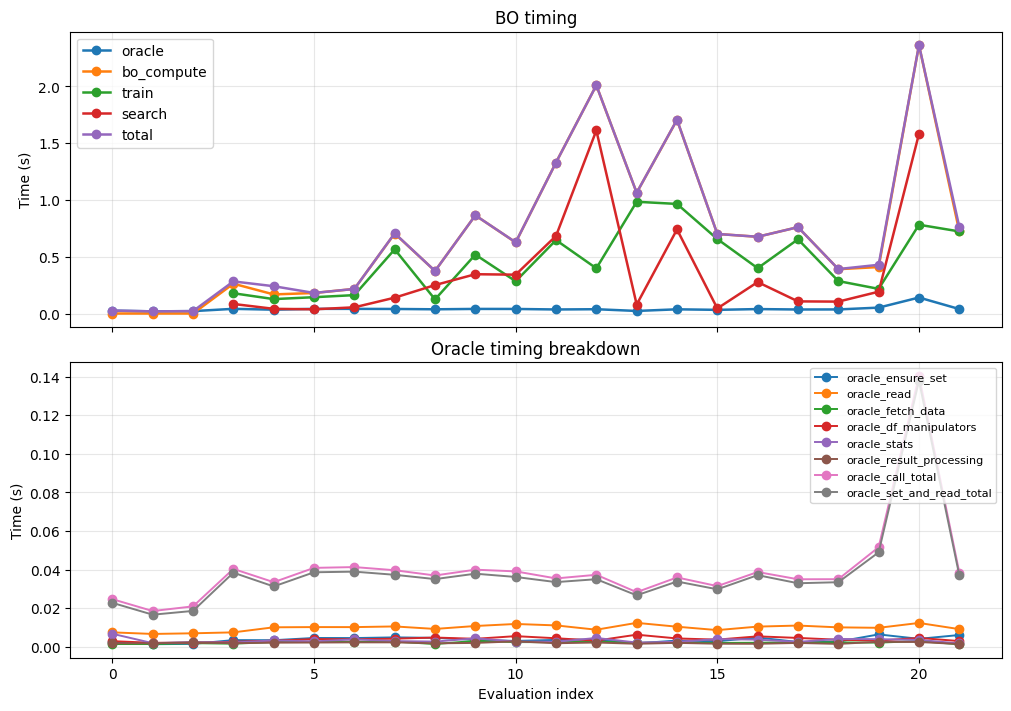

In [19]:
main_timing_keys = [k for k in ["oracle", "bo_compute", "train", "search", "total"] if k in timing_df.columns]
detail_preference = [
    "oracle_ensure_set",
    "machineio_ensure_set_base",
    "machineio_ensure_set_wait_after_ramp",
    "machineio_ensure_set_total",
    "oracle_read",
    "oracle_fetch_data",
    "machineio_fetch_data",
    "oracle_df_manipulators",
    "oracle_stats",
    "oracle_result_processing",
    "oracle_call_total",
    "oracle_set_and_read_total",
]
detail_timing_keys = [
    k for k in detail_preference
    if k in timing_df.columns and timing_df[k].notna().any()
]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
timing_df[main_timing_keys].plot(ax=axes[0], marker="o", linewidth=1.8)
axes[0].set_ylabel("Time (s)")
axes[0].set_title("BO timing")
axes[0].grid(True, alpha=0.3)

if detail_timing_keys:
    timing_df[detail_timing_keys].plot(ax=axes[1], marker="o", linewidth=1.4)
    axes[1].legend(loc="upper right", fontsize=8)
else:
    axes[1].text(0.5, 0.5, "No oracle detail timing keys found", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_xlabel("Evaluation index")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Oracle timing breakdown")
axes[1].grid(True, alpha=0.3)
plt.show()


In [20]:
x_hist = [h["x"] for h in bo.history]
y_hist = [h["y"] for h in bo.history]
imax = np.argmax(y_hist)
print("Best x:", x_hist[imax])
print("Best y:", y_hist[imax])

Best x: [ 0.14777488 -0.31723687  1.1157797   1.20054184]
Best y: [0.2284729]


# set best solution

In [21]:
oracle(x_hist[imax])

{'x': array([ 0.14796852, -0.31696084,  1.11606399,  1.20081473]),
 'y': array([0.22849683]),
 'timing': {'oracle_ensure_set': 0.002890200004912913,
  'oracle_ramping_validate': 0.004189100000075996,
  'oracle_ramping_df_manipulators': 0.00227269995957613,
  'oracle_ramping_stats': 0.001838900032453239,
  'oracle_read': 0.007752700010314584,
  'oracle_fetch_data': 0.0013391999527812004,
  'oracle_validate_data': 0.0035800000187009573,
  'oracle_df_manipulators': 0.0028249999741092324,
  'oracle_read_total': 0.00774419994559139,
  'oracle_stats': 0.0019953999435529113,
  'oracle_set_and_read_total': 0.020958299981430173,
  'oracle_result_processing': 0.0015434999950230122,
  'oracle_call_total': 0.02253970003221184}}

In [22]:
monitor_live

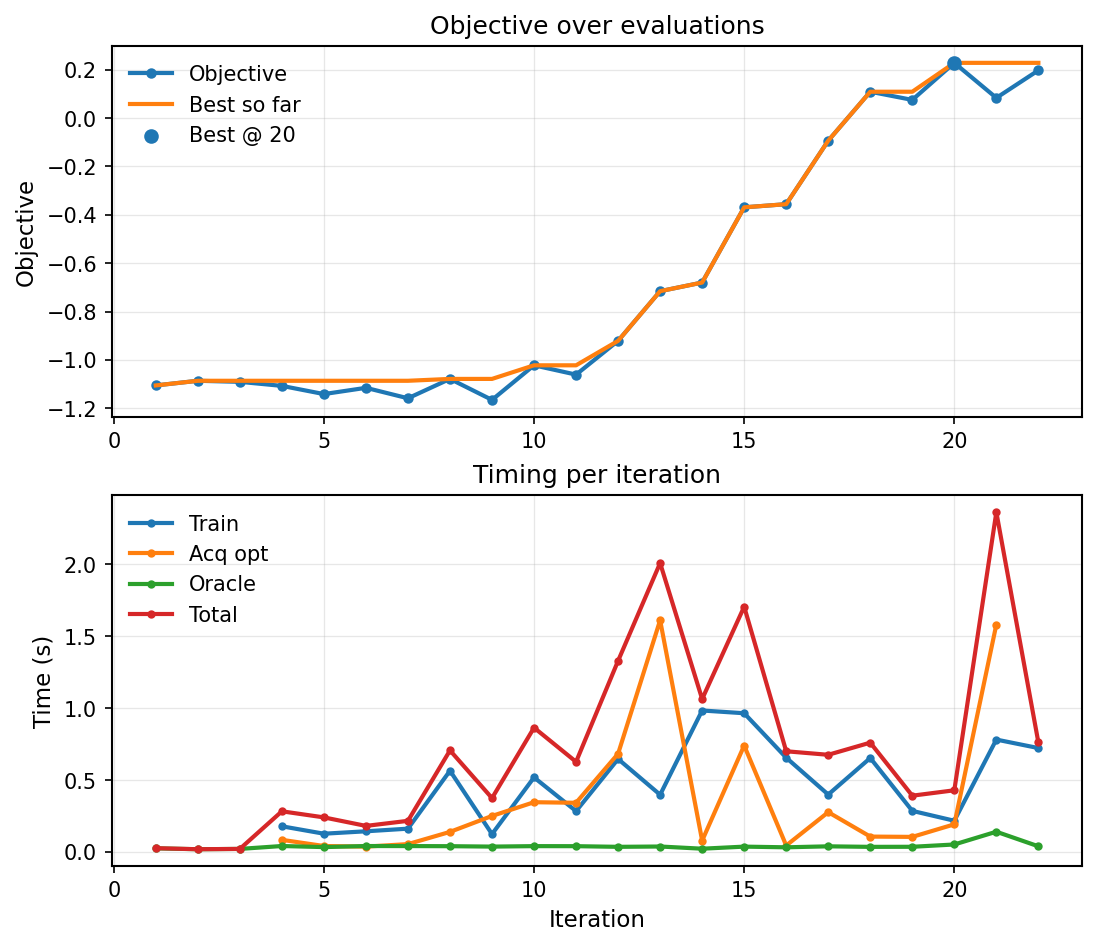

(<Figure size 1080x930 with 2 Axes>,
 (<AxesSubplot: title={'center': 'Objective over evaluations'}, ylabel='Objective'>,
  <AxesSubplot: title={'center': 'Timing per iteration'}, xlabel='Iteration', ylabel='Time (s)'>))

In [23]:
bo.plot_history()